<a href="https://colab.research.google.com/github/anshubansal371/Predictive-Modeling-and-Profit-Optimization-for-Multi-Channel-Restaurant-Operations/blob/main/Predictive_Modeling_and_Profit_Optimization_for_Multi_Channel_Restaurant_Operations.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd

In [ ]:
file_path="/content/SkyCity Auckland Restaurants & Bars.csv"
df = pd.read_csv(file_path)

In [ ]:
print("Dataset loaded Successfully")
print(f"Shape of the dataset: {df.shape}")

Dataset loaded Successfully
Shape of the dataset: (1696, 30)


In [ ]:
df.head()

,CuisineType,RestaurantID,RestaurantName,Segment,Subregion,GrowthFactor,AOV,MonthlyOrders,InStoreOrders,InStoreRevenue,...,DeliveryCostPerOrder,SD_DeliveryTotalCost,InStoreNetProfit,UberEatsNetProfit,DoorDashNetProfit,SelfDeliveryNetProfit,InStoreShare,UE_share,DD_share,SD_share
0,Burgers,25731,Urban Burgers House,Cafe,North Shore,1.03,43.97,668,197,8662.09,...,3.25,458.25,3682.14,1352.45,752.78,2177.19,0.42,0.45,0.25,0.3
1,Burgers,25123,Urban Burgers Diner,QSR,South Auckland,1.05,40.45,1388,259,10476.55,...,4.72,1600.08,3605.72,1318.61,731.99,3119.38,0.23,0.45,0.25,0.3
2,Burgers,25177,King Burgers Eatery,Cafe,West Auckland,1.04,40.03,1717,524,20975.72,...,3.25,1163.50,7810.95,1555.90,863.42,4172.99,0.44,0.45,0.25,0.3
3,Burgers,25540,Classic Burgers Tavern,QSR,North Shore,1.03,36.28,1083,216,7836.48,...,0.89,231.40,2546.02,-72.25,-40.20,2833.26,0.25,0.45,0.25,0.3
4,Burgers,25258,Lucky Burgers Bistro,Cafe,South Auckland,1.05,34.34,1230,261,8962.74,...,2.66,774.06,3093.09,226.17,125.53,2674.56,0.27,0.45,0.25,0.3


In [ ]:
print(f"The columns name: {df.columns.to_list()}")

The columns name: ['CuisineType', 'RestaurantID', 'RestaurantName', 'Segment', 'Subregion', 'GrowthFactor', 'AOV', 'MonthlyOrders', 'InStoreOrders', 'InStoreRevenue', 'UberEatsOrders', 'DoorDashOrders', 'SelfDeliveryOrders', 'UberEatsRevenue', 'DoorDashRevenue', 'SelfDeliveryRevenue', 'COGSRate', 'OPEXRate', 'CommissionRate', 'DeliveryRadiusKM', 'DeliveryCostPerOrder', 'SD_DeliveryTotalCost', 'InStoreNetProfit', 'UberEatsNetProfit', 'DoorDashNetProfit', 'SelfDeliveryNetProfit', 'InStoreShare', 'UE_share', 'DD_share', 'SD_share']


In [ ]:
df.info() #gives the information about the dataset

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1696 entries, 0 to 1695
Data columns (total 30 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   CuisineType            1696 non-null   object 
 1   RestaurantID           1696 non-null   int64  
 2   RestaurantName         1696 non-null   object 
 3   Segment                1696 non-null   object 
 4   Subregion              1696 non-null   object 
 5   GrowthFactor           1696 non-null   float64
 6   AOV                    1696 non-null   float64
 7   MonthlyOrders          1696 non-null   int64  
 8   InStoreOrders          1696 non-null   int64  
 9   InStoreRevenue         1696 non-null   float64
 10  UberEatsOrders         1696 non-null   int64  
 11  DoorDashOrders         1696 non-null   int64  
 12  SelfDeliveryOrders     1696 non-null   int64  
 13  UberEatsRevenue        1696 non-null   float64
 14  DoorDashRevenue        1696 non-null   float64
 15  Self

In [ ]:
print(f"Missing values:\n{df.isnull().sum()}")

Missing values:
CuisineType              0
RestaurantID             0
RestaurantName           0
Segment                  0
Subregion                0
GrowthFactor             0
AOV                      0
MonthlyOrders            0
InStoreOrders            0
InStoreRevenue           0
UberEatsOrders           0
DoorDashOrders           0
SelfDeliveryOrders       0
UberEatsRevenue          0
DoorDashRevenue          0
SelfDeliveryRevenue      0
COGSRate                 0
OPEXRate                 0
CommissionRate           0
DeliveryRadiusKM         0
DeliveryCostPerOrder     0
SD_DeliveryTotalCost     0
InStoreNetProfit         0
UberEatsNetProfit        0
DoorDashNetProfit        0
SelfDeliveryNetProfit    0
InStoreShare             0
UE_share                 0
DD_share                 0
SD_share                 0
dtype: int64


This confirms that there is no missing values in our dataset

In [ ]:
# Now checking channel share sum
df["TotalShare"] = (
    df["InStoreShare"] +
    df["UE_share"] +
    df["DD_share"] +
    df["SD_share"])
df["TotalShare"].describe()

,TotalShare
count,1696.000000
mean,1.225654
std,0.126977
min,1.030000
25%,1.110000
50%,1.210000
75%,1.320000
max,1.550000


In [ ]:
(df["UE_share"] + df["DD_share"] + df["SD_share"]).describe()

,0
count,1696.0
mean,1.0
std,0.0
min,1.0
25%,1.0
50%,1.0
75%,1.0
max,1.0


In [ ]:
# Delivery share of total orders
df["DeliveryShare"] = 1 - df["InStoreShare"]

# Corrected total-order channel shares (these extra 3 cloumns we keep)
df["UE_TotalShare"] = df["UE_share"] * df["DeliveryShare"]
df["DD_TotalShare"] = df["DD_share"] * df["DeliveryShare"]
df["SD_TotalShare"] = df["SD_share"] * df["DeliveryShare"]

# Final validation
df["FinalTotalShare"] = (df["InStoreShare"] +df["UE_TotalShare"] +df["DD_TotalShare"] +df["SD_TotalShare"])
df["FinalTotalShare"].describe()

,FinalTotalShare
count,1.696000e+03
mean,1.000000e+00
std,4.431056e-17
min,1.000000e+00
25%,1.000000e+00
50%,1.000000e+00
75%,1.000000e+00
max,1.000000e+00


In [ ]:
df["CalculatedOrders"] = (
    df["InStoreOrders"] +
    df["UberEatsOrders"] +
    df["DoorDashOrders"] +
    df["SelfDeliveryOrders"])

# Check mismatches
order_mismatch = df[df["CalculatedOrders"] != df["MonthlyOrders"]]
order_mismatch.shape

(0, 37)

The zero means there is no mismatch

In [ ]:
df["CalculatedTotalProfit"] = (
    df["InStoreNetProfit"] +
    df["UberEatsNetProfit"] +
    df["DoorDashNetProfit"] +
    df["SelfDeliveryNetProfit"])
df["CalculatedTotalProfit"].describe()

,CalculatedTotalProfit
count,1696.000000
mean,4638.152199
std,5829.596215
min,-10192.830000
25%,556.615000
50%,4932.860000
75%,8419.292500
max,27368.360000


In [ ]:
#checking the outliers
df[["CommissionRate","DeliveryCostPerOrder","DeliveryRadiusKM","COGSRate","OPEXRate"]].describe()

,CommissionRate,DeliveryCostPerOrder,DeliveryRadiusKM,COGSRate,OPEXRate
count,1696.000000,1696.000000,1696.000000,1696.000000,1696.000000
mean,0.300277,3.119363,10.565448,0.280149,0.411650
std,0.017931,1.344848,4.559197,0.061760,0.073420
min,0.270000,0.890000,3.000000,0.200369,0.200301
25%,0.280000,1.770000,6.000000,0.232270,0.372182
50%,0.300000,3.250000,11.000000,0.261271,0.411785
75%,0.320000,4.130000,14.000000,0.352189,0.456814
max,0.330000,5.310000,18.000000,0.399826,0.549688


All of them are in a realistic range so we call that there is no significant outliers in the dataset

In [ ]:
# Negative revenue check
(df[["InStoreRevenue","UberEatsRevenue","DoorDashRevenue","SelfDeliveryRevenue"]] < 0).sum()
#expecting all zeroes and we get that

,0
InStoreRevenue,0
UberEatsRevenue,0
DoorDashRevenue,0
SelfDeliveryRevenue,0


In [ ]:
#Dropping the columns which we don't further nedd of them.
df.drop(
    columns=[
        "TotalShare",
        "CalculatedOrders",
        "CalculatedTotalProfit",
        "DeliveryShare",
        "FinalTotalShare"],
    inplace=True,
    errors='ignore')
print(f"Shape after dropping: {df.shape}")
print(f"Columns after dropping {df.columns.tolist()}")

Shape after dropping: (1696, 33)
Columns after dropping ['CuisineType', 'RestaurantID', 'RestaurantName', 'Segment', 'Subregion', 'GrowthFactor', 'AOV', 'MonthlyOrders', 'InStoreOrders', 'InStoreRevenue', 'UberEatsOrders', 'DoorDashOrders', 'SelfDeliveryOrders', 'UberEatsRevenue', 'DoorDashRevenue', 'SelfDeliveryRevenue', 'COGSRate', 'OPEXRate', 'CommissionRate', 'DeliveryRadiusKM', 'DeliveryCostPerOrder', 'SD_DeliveryTotalCost', 'InStoreNetProfit', 'UberEatsNetProfit', 'DoorDashNetProfit', 'SelfDeliveryNetProfit', 'InStoreShare', 'UE_share', 'DD_share', 'SD_share', 'UE_TotalShare', 'DD_TotalShare', 'SD_TotalShare']


# EXPLORATORY DATA ANALYSIS (EDA)

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Recompute Total Monthly Net Profit (derived feature)
df["TotalNetProfit"] = (
    df["InStoreNetProfit"] +
    df["UberEatsNetProfit"] +
    df["DoorDashNetProfit"] +
    df["SelfDeliveryNetProfit"])
df["ProfitPerOrder"] = df["TotalNetProfit"] / df["MonthlyOrders"]

In [ ]:
df["TotalCostRate"] = df["COGSRate"] + df["OPEXRate"]
df["NetMarginRate"] = 1 - df["TotalCostRate"]
df["GrowthAdjustedOrders"] = df["MonthlyOrders"] * df["GrowthFactor"]

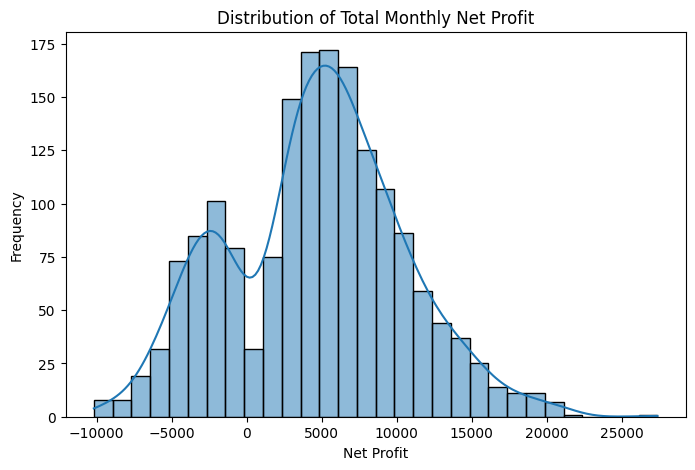

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df["TotalNetProfit"], bins=30, kde=True)
plt.title("Distribution of Total Monthly Net Profit")
plt.xlabel("Net Profit")
plt.ylabel("Frequency")
plt.show()

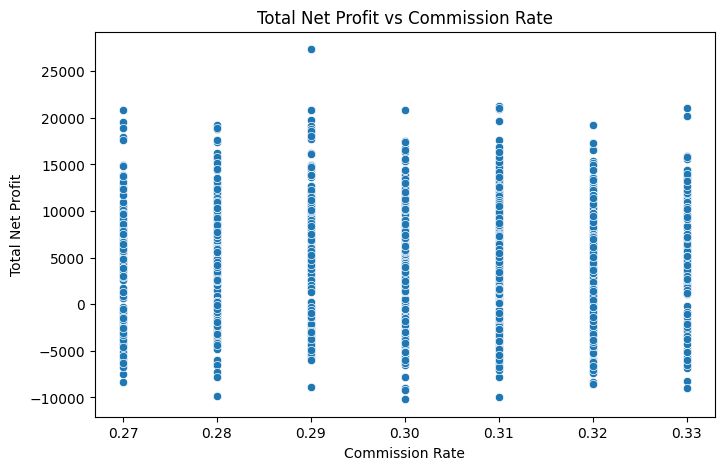

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    x=df["CommissionRate"],
    y=df["TotalNetProfit"])
plt.title("Total Net Profit vs Commission Rate")
plt.xlabel("Commission Rate")
plt.ylabel("Total Net Profit")
plt.show()

As the commission rates increas the total net profit decreases.In this plot each point represents the one restaurant month

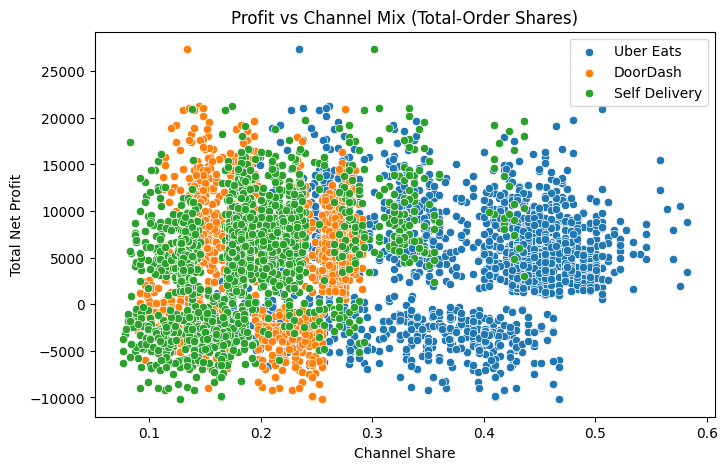

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=df["UE_TotalShare"], y=df["TotalNetProfit"], label="Uber Eats")
sns.scatterplot(x=df["DD_TotalShare"], y=df["TotalNetProfit"], label="DoorDash")
sns.scatterplot(x=df["SD_TotalShare"], y=df["TotalNetProfit"], label="Self Delivery")
plt.legend()
plt.title("Profit vs Channel Mix (Total-Order Shares)")
plt.xlabel("Channel Share")
plt.ylabel("Total Net Profit")
plt.show()

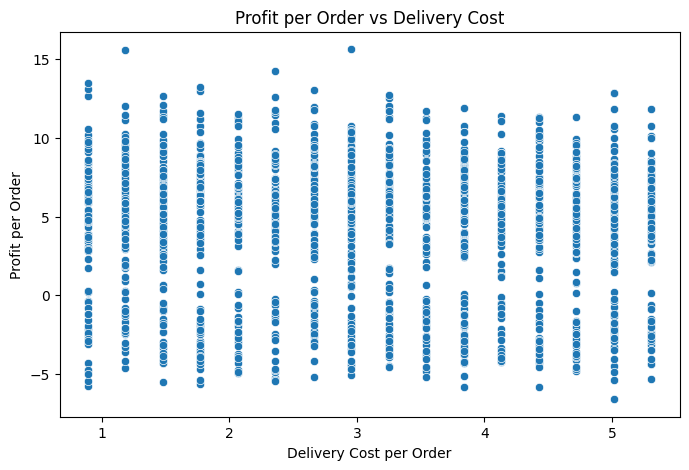

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    x=df["DeliveryCostPerOrder"],
    y=df["ProfitPerOrder"]
)
plt.title("Profit per Order vs Delivery Cost")
plt.xlabel("Delivery Cost per Order")
plt.ylabel("Profit per Order")
plt.show()


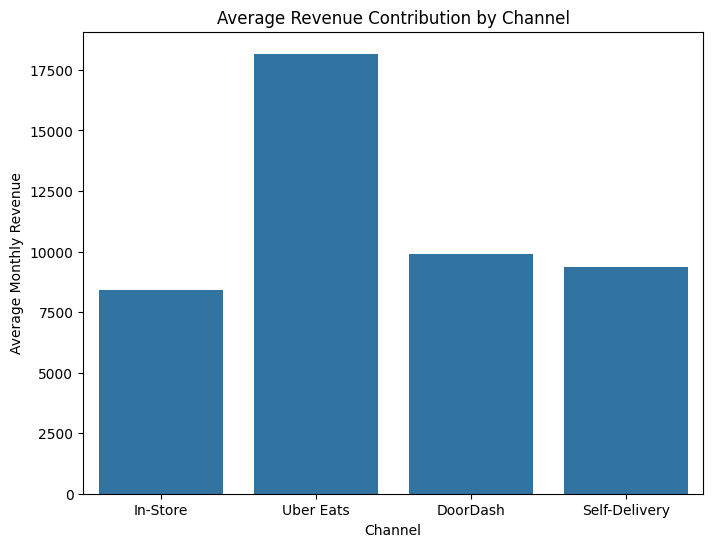

In [ ]:
channel_revenue = {
    "In-Store": df["InStoreRevenue"].mean(),
    "Uber Eats": df["UberEatsRevenue"].mean(),
    "DoorDash": df["DoorDashRevenue"].mean(),
    "Self-Delivery": df["SelfDeliveryRevenue"].mean()
}

plt.figure(figsize=(8,6))
sns.barplot(x=list(channel_revenue.keys()), y=list(channel_revenue.values()))
plt.title("Average Revenue Contribution by Channel")
plt.ylabel("Average Monthly Revenue")
plt.xlabel("Channel")
plt.show()

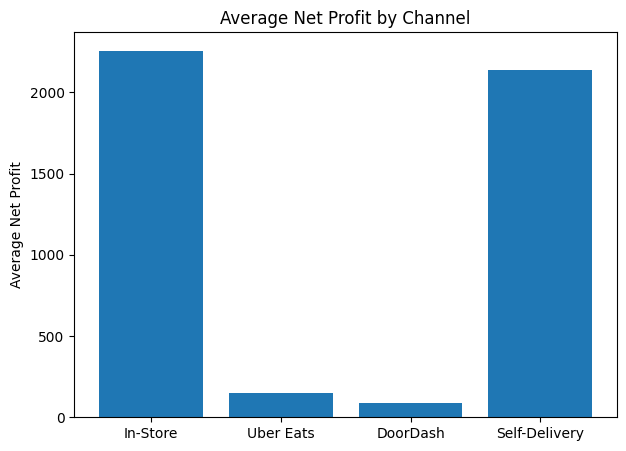

In [ ]:
channel_profit_means = {
    "In-Store": df["InStoreNetProfit"].mean(),
    "Uber Eats": df["UberEatsNetProfit"].mean(),
    "DoorDash": df["DoorDashNetProfit"].mean(),
    "Self-Delivery": df["SelfDeliveryNetProfit"].mean()
}

plt.figure(figsize=(7,5))
plt.bar(channel_profit_means.keys(), channel_profit_means.values())
plt.title("Average Net Profit by Channel")
plt.ylabel("Average Net Profit")
plt.show()

As we can see that most of the profit is form the In-Store and the Self-Delivery

# Feature Engineering (some of it is done earlier)

In [ ]:
df["TotalRevenue"] = (
    df["InStoreRevenue"] +
    df["UberEatsRevenue"] +
    df["DoorDashRevenue"] +
    df["SelfDeliveryRevenue"])

df["InStoreRevenueRatio"] = df["InStoreRevenue"] / df["TotalRevenue"]
df["UberEatsRevenueRatio"] = df["UberEatsRevenue"] / df["TotalRevenue"]
df["DoorDashRevenueRatio"] = df["DoorDashRevenue"] / df["TotalRevenue"]
df["SelfDeliveryRevenueRatio"] = df["SelfDeliveryRevenue"] / df["TotalRevenue"]

In [ ]:
df["DeliveryCost_SD_Interaction"] = (
    df["DeliveryCostPerOrder"] * df["SD_TotalShare"])
df["GrowthAdjustedOrders"] = df["MonthlyOrders"] * df["GrowthFactor"]

In [ ]:
df["Commission_UE_Interaction"] = df["CommissionRate"] * df["UE_TotalShare"]

final_features = [
    # Targets
    "TotalNetProfit",
    "ProfitPerOrder",

    # Channel mix (corrected)
    "InStoreShare",
    "UE_TotalShare",
    "DD_TotalShare",
    "SD_TotalShare",

    # Revenue dependency
    "InStoreRevenueRatio",
    "UberEatsRevenueRatio",
    "DoorDashRevenueRatio",
    "SelfDeliveryRevenueRatio",

    # Cost structure
    "CommissionRate",
    "DeliveryCostPerOrder",
    "TotalCostRate",
    "NetMarginRate",

    # Interaction terms
    "Commission_UE_Interaction",
    "DeliveryCost_SD_Interaction",

    # Demand
    "MonthlyOrders",
    "GrowthAdjustedOrders"
]
final_df = df[final_features]

In [ ]:
drop_cols = [
    "InStoreNetProfit","UberEatsNetProfit","DoorDashNetProfit","SelfDeliveryNetProfit",
    "ProfitPerOrder",
    "InStoreRevenue","UberEatsRevenue","DoorDashRevenue","SelfDeliveryRevenue",
    "TotalRevenue","InStoreRevenueRatio","UberEatsRevenueRatio",
    "DoorDashRevenueRatio","SelfDeliveryRevenueRatio",
    "TotalShare","CalculatedOrders","CalculatedTotalProfit",
    "DeliveryShare","FinalTotalShare",
    "RestaurantID","RestaurantName"
]

df = df.drop(columns=[c for c in drop_cols if c in df.columns])
# FINAL SAFE FEATURE SET (NO LEAKAGE)
safe_features = [
    # Channel mix (decision variables)
    "InStoreShare",
    "UE_TotalShare",
    "DD_TotalShare",
    "SD_TotalShare",

    # Cost & pricing drivers
    "CommissionRate",
    "DeliveryCostPerOrder",
    "TotalCostRate",

    # Interaction terms (allowed)
    "Commission_UE_Interaction",
    "DeliveryCost_SD_Interaction",

    # Demand drivers
    "MonthlyOrders",
    "GrowthAdjustedOrders"
]

X = df[safe_features]
y = df["TotalNetProfit"]

In [ ]:
from sklearn.model_selection import train_test_split
# Identify categorical columns for one-hot encoding
categorical_cols = X.select_dtypes(include='object').columns
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42)
len(X_train),len(y_train),len(X_test),len(y_test)

(1356, 1356, 340, 340)

Making the 80:20 train-test split and then training on different ML algorithms and a DL algorithm

In [ ]:
# Train the linear regression model
from sklearn.linear_model import LinearRegression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

LinearRegression()

In [ ]:
y_pred = lr_model.predict(X_test)
y_pred

array([ 5.77367278e+03,  7.34712784e+03,  7.90070261e+03,  1.10604574e+04,
        1.20718187e+04,  9.90660708e+03, -8.61487758e+02,  8.62680725e+03,
        5.25997025e+03,  1.00014221e+04,  4.30734294e+03,  7.00383033e+03,
        5.09651867e+03,  6.41071041e+03,  1.83974592e+03,  6.56277520e+02,
        3.86931643e+03, -6.53526486e+03,  6.05921548e+02,  4.43300862e+03,
        4.29326182e+03,  9.61172524e+03, -2.22238900e+03,  7.44951334e+03,
        4.21757484e+03,  6.50682418e+03,  9.58416404e+03,  8.95604656e+03,
        5.75384461e+03,  1.17480516e+03,  1.18567492e+04,  7.70017936e+03,
       -8.36052002e+03,  7.48327823e+03,  5.52068658e+03,  8.17520541e+03,
        1.20841956e+04,  5.59187657e+03, -1.03398847e+03, -2.20508942e+02,
        8.79063526e+03,  4.72659362e+03,  9.52360343e+03, -8.19686034e+03,
        1.03662602e+04,  5.91638525e+03,  1.65412753e+03, -2.51415466e+03,
        8.42231364e+03, -1.08868604e+03, -1.38023528e+03, -7.25203298e+03,
       -2.48666806e+02,  

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

lr_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
lr_mae = mean_absolute_error(y_test, y_pred)
lr_r2 = r2_score(y_test, y_pred)

print("Linear Regression Baseline Performance")
print("RMSE:", round(lr_rmse, 2))
print("MAE :", round(lr_mae, 2))
print("R²  :", round(lr_r2, 3))


Linear Regression Baseline Performance
RMSE: 2007.67
MAE : 1475.03
R²  : 0.875


In [ ]:
coefficients = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": lr_model.coef_
}).sort_values(by="Coefficient", ascending=False)

coefficients.head()

,Feature,Coefficient
1,UE_TotalShare,8231.512470
3,SD_TotalShare,5635.110255
5,DeliveryCostPerOrder,21.096133
10,GrowthAdjustedOrders,5.117206
9,MonthlyOrders,-1.427498


In [ ]:
commission_coef = coefficients[coefficients["Feature"] == "CommissionRate"]["Coefficient"].values[0]
print("CommissionRate coefficient:", round(commission_coef, 2))
#CommissionRate = 0.0 does NOT mean commission has no effect; it means its effect is fully captured through interaction with Uber Eats share.

CommissionRate coefficient: -5521.87


In [ ]:
impact_1_percent = commission_coef * 0.01
print("Impact of 1% increase in commission on monthly profit:",round(impact_1_percent, 2))

Impact of 1% increase in commission on monthly profit: -55.22


In [ ]:
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
rf_mae = mean_absolute_error(y_test, y_pred_rf)
rf_r2 = r2_score(y_test, y_pred_rf)

In [ ]:
print("Random Forest Performance")
print("RMSE:", round(rf_rmse, 2))
print("MAE :", round(rf_mae, 2))
print("R²  :", round(rf_r2, 3))

Random Forest Performance
RMSE: 1135.28
MAE : 840.26
R²  : 0.96


In [ ]:
from sklearn.ensemble import GradientBoostingRegressor
gbr = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gbr.fit(X_train, y_train)
y_pred_gbr = gbr.predict(X_test)

In [ ]:
gbr_rmse = np.sqrt(mean_squared_error(y_test, y_pred_gbr))
gbr_mae = mean_absolute_error(y_test, y_pred_gbr)
gbr_r2 = r2_score(y_test, y_pred_gbr)

print("Gradient Boosting Performance")
print("RMSE:", round(gbr_rmse, 2))
print("MAE :", round(gbr_mae, 2))
print("R²  :", round(gbr_r2, 3))

Gradient Boosting Performance
RMSE: 1072.61
MAE : 811.56
R²  : 0.964


In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras import layers
from tensorflow.keras.layers import Dense

model = Sequential([
    layers.Dense(128, activation="relu", input_shape=(X_train_scaled.shape[1],)),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.2),
    layers.Dense(1)  # Regression output
])

model.compile(loss="mae",
    optimizer=tf.keras.optimizers.Adam(),
    metrics=["mae"]
)

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         1,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,857 (38.50 KB)

 Trainable params: 9,857 (38.50 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    verbose=1
)

Epoch 1/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 4s 53ms/step - loss: 6359.0020 - mae: 6359.0020 - val_loss: 5967.1240 - val_mae: 5967.1240
Epoch 2/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6308.1646 - mae: 6308.1646 - val_loss: 5958.5552 - val_mae: 5958.5552
Epoch 3/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6343.1138 - mae: 6343.1138 - val_loss: 5933.2290 - val_mae: 5933.2290
Epoch 4/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 5953.3633 - mae: 5953.3633 - val_loss: 5875.6045 - val_mae: 5875.6045
Epoch 5/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6105.4375 - mae: 6105.4375 - val_loss: 5769.4487 - val_mae: 5769.4487
Epoch 6/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 5954.1523 - mae: 5954.1523 - val_loss: 5597.5713 - val_mae: 5597.5713
Epoch 7/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 5706.0098 - mae: 5706.0098 - val_loss: 5353.8589 - val_mae: 5353.8589
Epoch 8/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 5601.2368 - mae: 5601.2368 - val_loss

In [ ]:
y_pred_dl = model.predict(X_test_scaled).flatten()

dl_rmse = np.sqrt(mean_squared_error(y_test, y_pred_dl))
dl_mae = mean_absolute_error(y_test, y_pred_dl)
dl_r2 = r2_score(y_test, y_pred_dl)

print("Deep Learning (MLP) Performance")
print("RMSE:", round(dl_rmse, 2))
print("MAE :", round(dl_mae, 2))
print("R²  :", round(dl_r2, 3))

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
Deep Learning (MLP) Performance
RMSE: 1049.46
MAE : 803.69
R²  : 0.966


In [ ]:
comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "Gradient Boosting",
        "Deep Learning (MLP)"
    ],
    "RMSE": [lr_rmse, rf_rmse, gbr_rmse, dl_rmse],
    "MAE": [lr_mae, rf_mae, gbr_mae, dl_mae],
    "R²": [lr_r2, rf_r2, gbr_r2, dl_r2]
})

comparison

,Model,RMSE,MAE,R²
0,Linear Regression,2007.673840,1475.034830,0.874684
1,Random Forest,1135.282698,840.256967,0.959929
2,Gradient Boosting,1072.608005,811.556331,0.964231
3,Deep Learning (MLP),1049.458994,803.693478,0.965759


In [ ]:
best_model = comparison.sort_values(by="RMSE").iloc[0]
best_model

,3
Model,Deep Learning (MLP)
RMSE,1049.458994
MAE,803.693478
R²,0.965759


# Understanding the risk of changing the commision rate, UE share and SD share

In [ ]:
X_base = df[safe_features].copy()
X_base_scaled = scaler.transform(X_base)
# Gradient Boosting
baseline_gbr = gbr.predict(X_base).mean()

# Deep Learning (use the SAME rows and scaling)
baseline_dl = model.predict(X_base_scaled).mean()
#baseline_gbr, baseline_dl
baseline_profit=baseline_gbr

53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [ ]:
baseline_profit

np.float64(4638.394086651532)

This is the baseline profit of a resturant in a month before changing the commision rate or other parameters

In [ ]:
commission_changes = [0.01, 0.05, 0.10]

commission_results = []

for change in commission_changes:
    X_sim = X_base.copy()

    # Increase commission
    X_sim["CommissionRate"] *= (1 + change)

    # Update interaction term
    X_sim["Commission_UE_Interaction"] = (
        X_sim["CommissionRate"] * X_sim["UE_TotalShare"])

    new_profit = gbr.predict(X_sim).mean()

    pct_change = ((new_profit - baseline_profit) / baseline_profit) * 100

    commission_results.append([
        f"Commision+{int(change*100)}%",
        new_profit,
        pct_change
    ])

In [ ]:
channel_results = []

# Uber Eats share increase
X_ue = X_base.copy()
X_ue["UE_TotalShare"] *= 1.10
X_ue["Commission_UE_Interaction"] = (
    X_ue["CommissionRate"] * X_ue["UE_TotalShare"]
)

ue_profit = gbr.predict(X_ue).mean()
ue_pct_change = ((ue_profit - baseline_profit) / baseline_profit) * 100

channel_results.append([
    "UE Share +10%",
    ue_profit,
    ue_pct_change])

# Self-Delivery share increase
X_sd = X_base.copy()
X_sd["SD_TotalShare"] *= 1.10
X_sd["DeliveryCost_SD_Interaction"] = (
    X_sd["DeliveryCostPerOrder"] * X_sd["SD_TotalShare"])

sd_profit = gbr.predict(X_sd).mean()
sd_pct_change = ((sd_profit - baseline_profit) / baseline_profit) * 100
channel_results.append([
    "Self-Delivery Share +10%",
    sd_profit,
    sd_pct_change])
channel_results

[['UE Share +10%',
  np.float64(4350.49735552942),
  np.float64(-6.206819121959203)],
 ['Self-Delivery Share +10%',
  np.float64(4711.652762680445),
  np.float64(1.579397409110592)]]

In [ ]:
sensitivity_table = pd.DataFrame(
    commission_results + channel_results,
    columns=["Scenario","Predicted Avg Profit","% Profit Change"])
sensitivity_table

,Scenario,Predicted Avg Profit,% Profit Change
0,Commision+1%,4609.625679,-0.620223
1,Commision+5%,4363.268605,-5.931481
2,Commision+10%,4067.026576,-12.318218
3,UE Share +10%,4350.497356,-6.206819
4,Self-Delivery Share +10%,4711.652763,1.579397


In [ ]:
sensitivity_table["Profit Changes"] = (sensitivity_table["Predicted Avg Profit"] - baseline_profit)
sensitivity_table

,Scenario,Predicted Avg Profit,% Profit Change,Profit Changes
0,Commision+1%,4609.625679,-0.620223,-28.768407
1,Commision+5%,4363.268605,-5.931481,-275.125481
2,Commision+10%,4067.026576,-12.318218,-571.367510
3,UE Share +10%,4350.497356,-6.206819,-287.896731
4,Self-Delivery Share +10%,4711.652763,1.579397,73.258676


In [ ]:
psi = (abs(sensitivity_table["% Profit Change"]).mean())
psi
#It shows the Profit Sensitivity Index — the average absolute percentage change in profit caused by small changes in key variables, representing how financially sensitive (risky) the business is overall

np.float64(5.331227934654032)

/tmp/ipython-input-4262039064.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


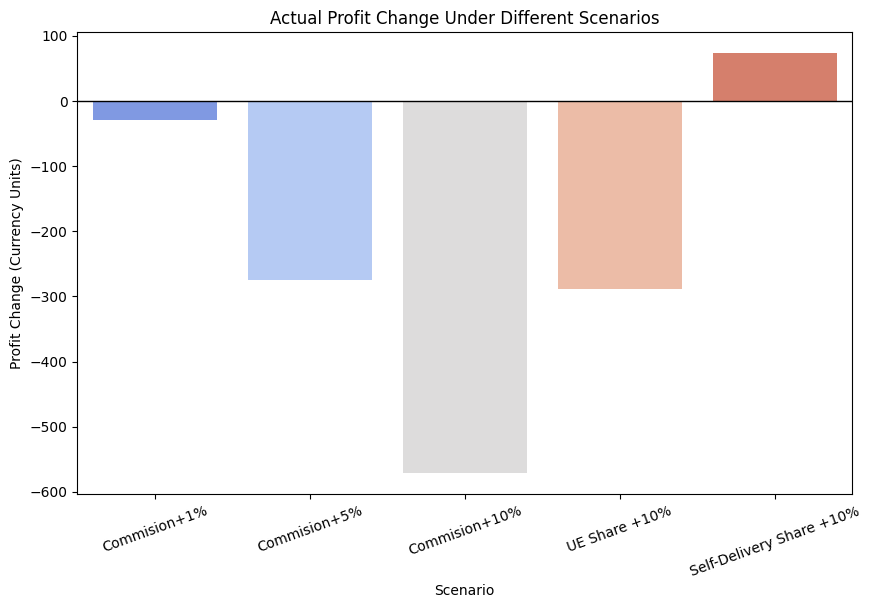

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.barplot(
    x="Scenario",
    y="Profit Changes",
    data=sensitivity_table,
    palette="coolwarm")

plt.axhline(0, color="black", linewidth=1)
plt.title("Actual Profit Change Under Different Scenarios")
plt.ylabel("Profit Change (Currency Units)")
plt.xlabel("Scenario")
plt.xticks(rotation=20)
plt.show()

As we can see that there is only increase in the profit if we use self delivery except that there is some loss in the profit for each condition we're taking.

In [ ]:
commission_range = np.arange(0.25, 0.41, 0.01)

commission_opt = []

for c in commission_range:
    X_sim = X_base.copy()
    X_sim["CommissionRate"] = c
    X_sim["Commission_UE_Interaction"] = c * X_sim["UE_TotalShare"]

    profit = gbr.predict(X_sim).mean()
    commission_opt.append([c, profit])
commission_df = pd.DataFrame(
    commission_opt,
    columns=["CommissionRate", "PredictedProfit"])
commission_df

,CommissionRate,PredictedProfit
0,0.25,5622.031683
1,0.26,5520.181450
2,0.27,5405.269657
3,0.28,5161.953132
4,0.29,4945.503231
5,0.30,4616.496069
6,0.31,4387.319793
7,0.32,4113.408158
8,0.33,3971.026582
9,0.34,3896.698333


In [ ]:
baseline_profit # if the ccmmission get lower than the profit can be increased

np.float64(4638.394086651532)

In [ ]:
break_even_commission = commission_df[
    commission_df["PredictedProfit"] <= baseline_profit
].iloc[0]["CommissionRate"]

print(f"Break-even commission rate is {break_even_commission:.2%}.Above this level, predicted profit falls below the current baseline.")
 # if the commision increases from this amount then there is a impact on the baseline profit.

Break-even commission rate is 30.00%.Above this level, predicted profit falls below the current baseline.


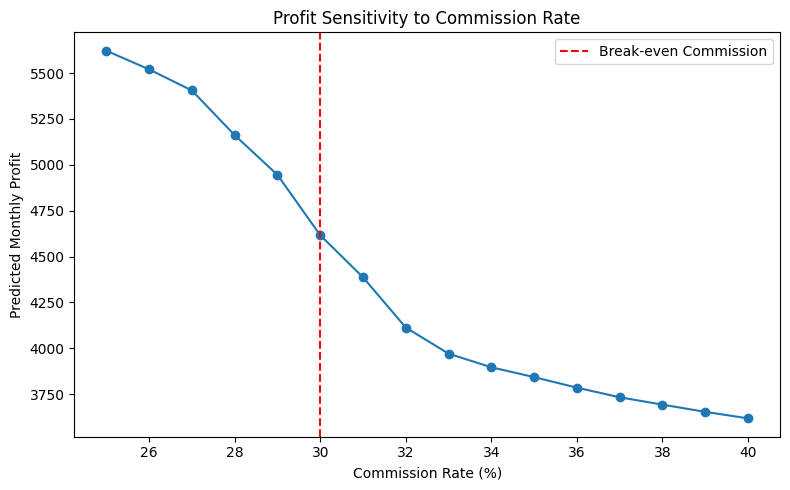

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(
    commission_df["CommissionRate"] * 100,
    commission_df["PredictedProfit"],
    marker="o")

plt.axvline(
    break_even_commission * 100,
    color="red",
    linestyle="--",
    label="Break-even Commission")

plt.title("Profit Sensitivity to Commission Rate")
plt.xlabel("Commission Rate (%)")
plt.ylabel("Predicted Monthly Profit")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
sd_range = np.arange(0.05, 0.41, 0.05)

sd_results = []

for sd in sd_range:
    X_sim = X_base.copy()

    # Adjust shares
    X_sim["SD_TotalShare"] = sd
    X_sim["UE_TotalShare"] = X_sim["UE_TotalShare"] * (1 - sd)

    # Update interaction
    X_sim["DeliveryCost_SD_Interaction"] = (
        X_sim["DeliveryCostPerOrder"] * X_sim["SD_TotalShare"])

    profit = gbr.predict(X_sim).mean()
    sd_results.append([sd, profit])
sd_df = pd.DataFrame(
    sd_results,
    columns=["SelfDeliveryShare", "PredictedProfit"])

optimal_sd = sd_df.loc[sd_df["PredictedProfit"].idxmax()]

optimal_sd

,7
SelfDeliveryShare,0.400000
PredictedProfit,5292.207718


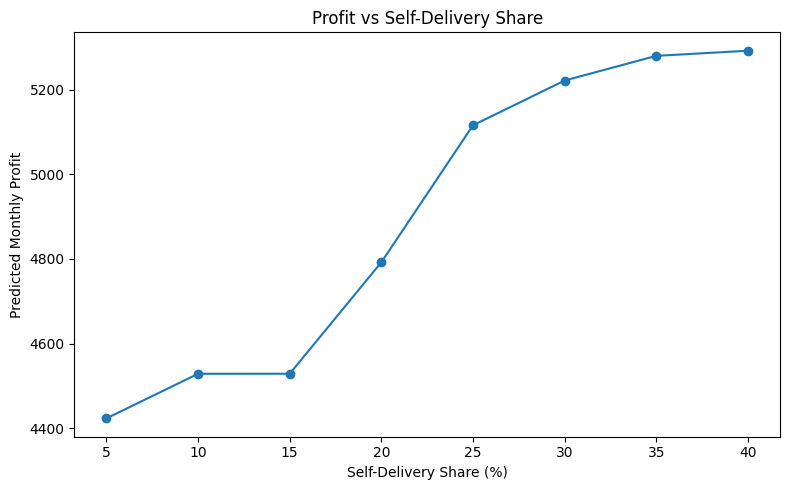

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(sd_df["SelfDeliveryShare"] * 100,
         sd_df["PredictedProfit"],
         marker="o")

plt.title("Profit vs Self-Delivery Share")
plt.xlabel("Self-Delivery Share (%)")
plt.ylabel("Predicted Monthly Profit")
plt.tight_layout()
plt.show()

As we can see by increasing the self delivery share the profit also increases

In [ ]:
uplift_percent = ((optimal_sd["PredictedProfit"] - baseline_profit)/ baseline_profit) * 100

uplift_percent

np.float64(14.095689558421547)

In [ ]:
strategy_summary = pd.DataFrame({
    "Metric": ["Baseline Avg Profit",
               "Optimal Avg Profit",
               "Optimization Uplift (%)",
               "Break-Even Commission Rate",
               "Optimal Self-Delivery Share"
               ],"Value": [
        round(baseline_profit, 2),
        round(optimal_sd["PredictedProfit"], 2),
        round(uplift_percent, 2),
        round(break_even_commission, 2),
        round(optimal_sd["SelfDeliveryShare"], 2)
    ]
})

strategy_summary

,Metric,Value
0,Baseline Avg Profit,4638.39
1,Optimal Avg Profit,5292.21
2,Optimization Uplift (%),14.10
3,Break-Even Commission Rate,0.30
4,Optimal Self-Delivery Share,0.40


In [ ]:
def simulate_scenario(
    X_base,
    model,
    scenario_name,
    commission_rate=None,
    ue_share_increase=None,
    delivery_radius_km=None):
    X_sim = X_base.copy()

    # Scenario 1: Change commission
    if commission_rate is not None:
        X_sim["CommissionRate"] = commission_rate
        X_sim["Commission_UE_Interaction"] = (X_sim["CommissionRate"] * X_sim["UE_TotalShare"])

    # Scenario 2: Increase Uber Eats share
    if ue_share_increase is not None:
        X_sim["UE_TotalShare"] *= (1 + ue_share_increase)
        X_sim["Commission_UE_Interaction"] = (
            X_sim["CommissionRate"] * X_sim["UE_TotalShare"])

    # Scenario 3: Increase delivery radius (proxy via delivery cost)
    if delivery_radius_km is not None:
        # Assume delivery cost increases linearly with radius
        radius_factor = delivery_radius_km / 5
        X_sim["DeliveryCostPerOrder"] *= radius_factor
        X_sim["DeliveryCost_SD_Interaction"] = (
            X_sim["DeliveryCostPerOrder"] * X_sim["SD_TotalShare"])

    predicted_profit = model.predict(X_sim).mean()

    profit_change_pct = ((predicted_profit - baseline_profit) / baseline_profit) * 100

    return {
        "Scenario": scenario_name,
        "Predicted Profit": predicted_profit,
        "% Profit Change": profit_change_pct
    }

In [ ]:
scenario_1 = simulate_scenario(X_base,gbr,scenario_name="Uber Eats Share +10%",ue_share_increase=0.10)
scenario_2 = simulate_scenario(X_base,gbr,scenario_name="Commission Increase 25% → 30%",commission_rate=0.30)
scenario_3 = simulate_scenario(X_base,gbr,scenario_name="Delivery Radius Increase 5 → 10 km",delivery_radius_km=10)

In [ ]:
scenario_results = pd.DataFrame([scenario_1,scenario_2,scenario_3])

# Add absolute profit change
scenario_results["Reduction in Profit"] = (scenario_results["Predicted Profit"] - baseline_profit)

scenario_results.round(2)

,Scenario,Predicted Profit,% Profit Change,Reduction in Profit
0,Uber Eats Share +10%,4350.50,-6.21,-287.90
1,Commission Increase 25% → 30%,4616.50,-0.47,-21.90
2,Delivery Radius Increase 5 → 10 km,4383.68,-5.49,-254.71


In [ ]:
results = []

for sd in np.arange(0.05, 0.31, 0.05):   # SD capped at 30%
    for ue in np.arange(0.20, 0.61, 0.05):  # UE minimum 20%

        dd = 1 - (sd + ue)
        if dd < 0:
            continue

        X_sim = X_base.copy()
        X_sim["SD_TotalShare"] = sd
        X_sim["UE_TotalShare"] = ue
        X_sim["DD_TotalShare"] = dd

        X_sim["Commission_UE_Interaction"] = (X_sim["CommissionRate"] * ue)
        X_sim["DeliveryCost_SD_Interaction"] = (X_sim["DeliveryCostPerOrder"] * sd)

        profit = gbr.predict(X_sim).mean()

        results.append([sd, ue, dd, profit])

In [ ]:
constrained_df = pd.DataFrame(results,
                              columns=["SD_Share", "UE_Share", "DD_Share", "PredictedProfit"])

best_constrained = constrained_df.loc[constrained_df["PredictedProfit"].idxmax()]

best_constrained

,45
SD_Share,0.300000
UE_Share,0.200000
DD_Share,0.500000
PredictedProfit,6342.768992


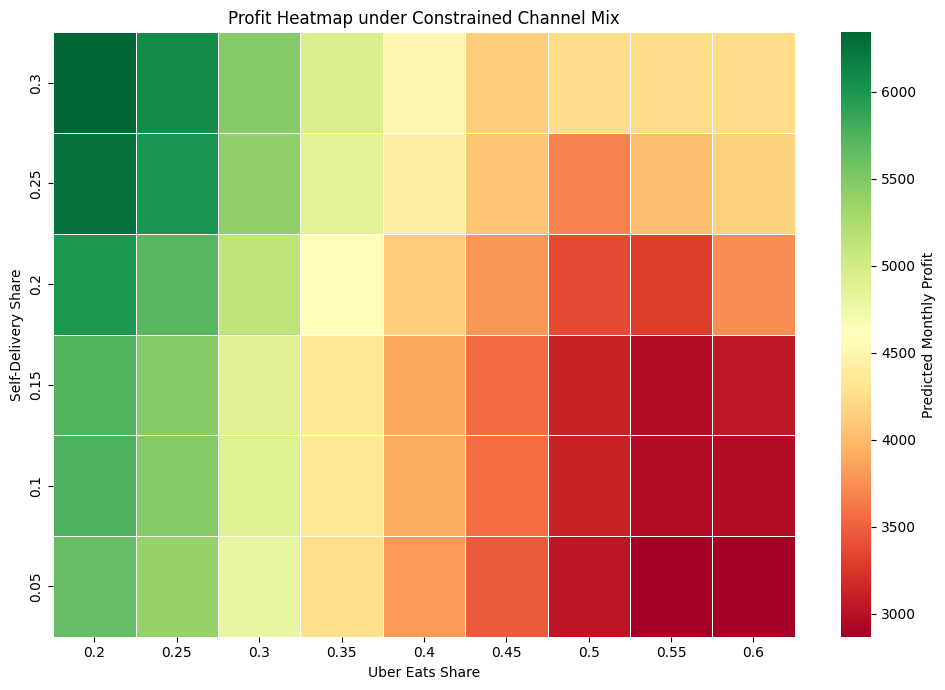

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Round shares for clean axes
constrained_df["SD_Share"] = constrained_df["SD_Share"].round(2)
constrained_df["UE_Share"] = constrained_df["UE_Share"].round(2)

# Create pivot table with proper sorting
pivot_profit = constrained_df.pivot_table(index="SD_Share",
                                          columns="UE_Share",
                                          values="PredictedProfit",
                                          aggfunc="mean").sort_index().sort_index(axis=1)

plt.figure(figsize=(10,7))

sns.heatmap(pivot_profit,
            cmap="RdYlGn",
            annot=False,
            linewidths=0.5,
            cbar_kws={"label": "Predicted Monthly Profit"}
)

# Flip y-axis so lower SD is at bottom (intuitive)
plt.gca().invert_yaxis()

plt.title("Profit Heatmap under Constrained Channel Mix")
plt.xlabel("Uber Eats Share")
plt.ylabel("Self-Delivery Share")

plt.tight_layout()
plt.show()

# KPI :- Key Performance Indicator
A single number that tells management how the business is performing and what action is needed.

In [ ]:
predicted_net_profit = gbr.predict(X_base).mean()
predicted_net_profit

np.float64(4638.394086651532)

In [ ]:
total_delivery_share = (
    X_base["UE_TotalShare"] +
    X_base["DD_TotalShare"] +
    X_base["SD_TotalShare"]).mean()

channel_mix_efficiency = predicted_net_profit / total_delivery_share
channel_mix_efficiency

np.float64(5990.083203984649)

In [ ]:
break_even_commission

np.float64(0.30000000000000004)

In [ ]:
optimization_uplift_pct = (
    (optimal_sd["PredictedProfit"] - baseline_profit)
    / baseline_profit
) * 100

optimization_uplift_pct

np.float64(14.095689558421547)

In [ ]:
profit_stability_index = 1 / (1 + psi)
profit_stability_index
# The business is highly sensitive to changes in costs and channel mix. As it is near to zero

np.float64(0.15794724346070235)

In [ ]:
commission_risk_flag = (
    "High Risk"
    if X_base["CommissionRate"].mean() > break_even_commission
    else "Safe")

commission_risk_flag
#Immediate attention is needed on commission negotiations or channel dependence.

'High Risk'

In [ ]:
self_delivery_readiness = (
    optimal_sd["SelfDeliveryShare"] / 0.30
)

self_delivery_readiness
#1.33 means:
#Self-delivery can be expanded
#But expansion must be controlled

np.float64(1.3333333333333335)

In [ ]:
kpi_table = pd.DataFrame({
    "KPI": [
        "Predicted Net Profit (Monthly)",
        "Channel Mix Efficiency Score",
        "Break-even Commission Rate",
        "Optimization Uplift (%)",
        "Profit Stability Index",
        "Commission Risk Status",
        "Self-Delivery Readiness Score"
    ],
    "Value": [
        round(predicted_net_profit, 2),
        round(channel_mix_efficiency, 2),
        f"{break_even_commission:.2%}",
        round(optimization_uplift_pct, 2),
        round(profit_stability_index, 2),
        commission_risk_flag,
        round(self_delivery_readiness, 2)
    ]
})

kpi_table

,KPI,Value
0,Predicted Net Profit (Monthly),4638.39
1,Channel Mix Efficiency Score,5990.08
2,Break-even Commission Rate,30.00%
3,Optimization Uplift (%),14.1
4,Profit Stability Index,0.16
5,Commission Risk Status,High Risk
6,Self-Delivery Readiness Score,1.33


In [ ]:
import joblib
joblib.dump(gbr, "final_profit_model.pkl")

['final_profit_model.pkl']

In [ ]:
joblib.dump(X_base.columns.tolist(), "model_features.pkl")

['model_features.pkl']

In [ ]:
model = joblib.load("final_profit_model.pkl")
features = joblib.load("model_features.pkl")